# Lab 4.1 - Exercise 3: CIFAR-10 (Basic CNN vs VGG vs ResNet)

**Student**: 22521609 - Pham Duy Tuan

In [13]:
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

print('Torch version:', torch.__version__)

Torch version: 2.5.1+cu121


In [14]:
# Hyperparameters
BATCH_SIZE = 128
LR = 1e-3
EPOCHS = 5
RANDOM_SEED = 42
NUM_CLASSES = 10

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [15]:
# CIFAR-10 mean/std (commonly used)
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_dataset.classes
print('Train size:', len(train_dataset))
print('Test size :', len(test_dataset))
print('Classes   :', class_names)

100.0%


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Train size: 50000
Test size : 10000
Classes   : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


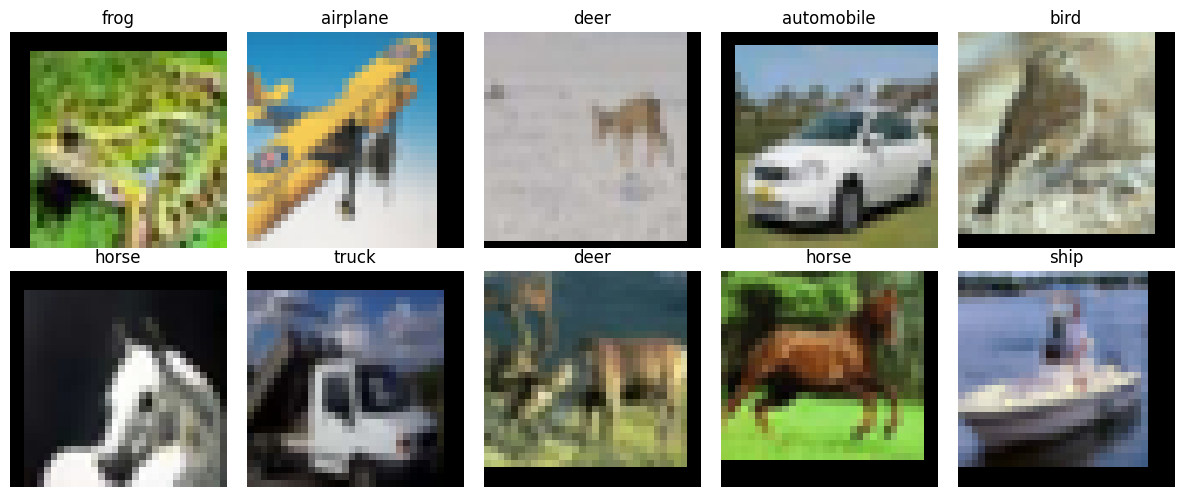

In [16]:
# Visualize some training samples (denormalized)
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[labels[i].item()])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [17]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def build_vgg(num_classes=10):
    model = models.vgg16(weights=None)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


def build_resnet(num_classes=10):
    model = models.resnet18(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

In [18]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / total, correct / total


def run_training(model, model_name, train_loader, test_loader, device, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
    }

    best_acc = 0.0
    best_state = None

    print(f'\nTraining {model_name}...')
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)

        if te_acc > best_acc:
            best_acc = te_acc
            best_state = copy.deepcopy(model.state_dict())

        print(
            f'Epoch {epoch:02d}/{epochs} | '
            f'Train loss: {tr_loss:.4f}, acc: {tr_acc:.4f} | '
            f'Test loss: {te_loss:.4f}, acc: {te_acc:.4f}'
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [19]:
# Initialize models
basic_cnn = BasicCNN(NUM_CLASSES).to(device)
vgg_model = build_vgg(NUM_CLASSES).to(device)
resnet_model = build_resnet(NUM_CLASSES).to(device)

print('Models initialized.')

Models initialized.


In [20]:
# Train Basic CNN
history_basic = run_training(
    basic_cnn,
    model_name='Basic CNN',
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=EPOCHS,
    lr=LR,
)


Training Basic CNN...
Epoch 01/5 | Train loss: 1.6473, acc: 0.3939 | Test loss: 1.2772, acc: 0.5416
Epoch 02/5 | Train loss: 1.2828, acc: 0.5368 | Test loss: 1.0812, acc: 0.6116
Epoch 03/5 | Train loss: 1.1006, acc: 0.6082 | Test loss: 0.9264, acc: 0.6719
Epoch 04/5 | Train loss: 0.9762, acc: 0.6555 | Test loss: 0.8697, acc: 0.6918
Epoch 05/5 | Train loss: 0.9052, acc: 0.6820 | Test loss: 0.7838, acc: 0.7317


In [21]:
# Train VGG16
history_vgg = run_training(
    vgg_model,
    model_name='VGG16',
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=EPOCHS,
    lr=LR,
)


Training VGG16...
Epoch 01/5 | Train loss: 2.5306, acc: 0.0969 | Test loss: 2.3026, acc: 0.1000
Epoch 02/5 | Train loss: 2.3028, acc: 0.0984 | Test loss: 2.3026, acc: 0.1000
Epoch 03/5 | Train loss: 2.3027, acc: 0.0991 | Test loss: 2.3026, acc: 0.1000
Epoch 04/5 | Train loss: 2.3027, acc: 0.0978 | Test loss: 2.3026, acc: 0.1000
Epoch 05/5 | Train loss: 2.3027, acc: 0.0975 | Test loss: 2.3026, acc: 0.1000


In [22]:
# Train ResNet18
history_resnet = run_training(
    resnet_model,
    model_name='ResNet18',
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=EPOCHS,
    lr=LR,
)


Training ResNet18...
Epoch 01/5 | Train loss: 1.5439, acc: 0.4345 | Test loss: 1.3183, acc: 0.5346
Epoch 02/5 | Train loss: 1.1770, acc: 0.5775 | Test loss: 1.0885, acc: 0.6161
Epoch 03/5 | Train loss: 1.0098, acc: 0.6400 | Test loss: 1.0159, acc: 0.6460
Epoch 04/5 | Train loss: 0.9026, acc: 0.6827 | Test loss: 0.9270, acc: 0.6849
Epoch 05/5 | Train loss: 0.8316, acc: 0.7078 | Test loss: 0.7977, acc: 0.7229


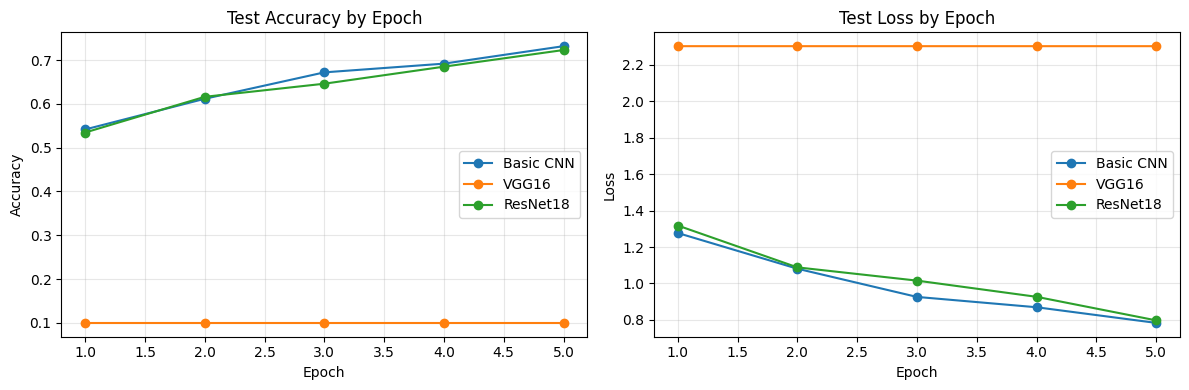

In [23]:
# Plot test accuracy and test loss comparison
epoch_axis = np.arange(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epoch_axis, history_basic['test_acc'], marker='o', label='Basic CNN')
axes[0].plot(epoch_axis, history_vgg['test_acc'], marker='o', label='VGG16')
axes[0].plot(epoch_axis, history_resnet['test_acc'], marker='o', label='ResNet18')
axes[0].set_title('Test Accuracy by Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epoch_axis, history_basic['test_loss'], marker='o', label='Basic CNN')
axes[1].plot(epoch_axis, history_vgg['test_loss'], marker='o', label='VGG16')
axes[1].plot(epoch_axis, history_resnet['test_loss'], marker='o', label='ResNet18')
axes[1].set_title('Test Loss by Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Final summary
final_results = {
    'Basic CNN': {
        'test_acc': history_basic['test_acc'][-1],
        'test_loss': history_basic['test_loss'][-1],
    },
    'VGG16': {
        'test_acc': history_vgg['test_acc'][-1],
        'test_loss': history_vgg['test_loss'][-1],
    },
    'ResNet18': {
        'test_acc': history_resnet['test_acc'][-1],
        'test_loss': history_resnet['test_loss'][-1],
    },
}

print('Final test results:')
for name, vals in final_results.items():
    print(f"  {name:10s} | acc: {vals['test_acc']:.4f} | loss: {vals['test_loss']:.4f}")

best_model = max(final_results, key=lambda k: final_results[k]['test_acc'])
print(f"\nBest model by final test accuracy: {best_model}")

Final test results:
  Basic CNN  | acc: 0.7317 | loss: 0.7838
  VGG16      | acc: 0.1000 | loss: 2.3026
  ResNet18   | acc: 0.7229 | loss: 0.7977

Best model by final test accuracy: Basic CNN


: 